# Feature Selection with Filter Methods

Feature selection helps reduce noise and retain only the variables that contribute meaningfully to prediction. Filter based feature selection methods evaluate each feature independently of the model.

Let's apply filter based techniques to assess features' relevance to the target variable. We will score features using correlation (linear) and mutual information (non-linear).



#### Loading Data

For this, we will use the Red Wine Quality dataset from the UCI repository. Each row represents a wine sample described by physical and chemical measurements (e.g. acidity, sulphates, alcohol), and the target variable is a sensory quality score assigned by experts.


In [47]:
# imports
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
import math
from sklearn.model_selection import KFold, train_test_split
from sklearn.feature_selection import mutual_info_regression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [4]:
df = pd.read_csv('./datasets/wine quality/winequality-white.csv', sep=';')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


All the predictor variables are numerical. Let's see the distribution

In [8]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000
mean,6.854788,0.278241,0.334192,6.391415,0.045772,35.308085,138.360657,0.994027,3.188267,0.489847,10.514267,5.877909
std,0.843868,0.100795,0.121020,5.072058,0.021848,17.007137,42.498065,0.002991,0.151001,0.114126,1.230621,0.885639
min,3.800000,0.080000,0.000000,0.600000,0.009000,2.000000,9.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.300000,0.210000,0.270000,1.700000,0.036000,23.000000,108.000000,0.991723,3.090000,0.410000,9.500000,5.000000
50%,6.800000,0.260000,0.320000,5.200000,0.043000,34.000000,134.000000,0.993740,3.180000,0.470000,10.400000,6.000000
75%,7.300000,0.320000,0.390000,9.900000,0.050000,46.000000,167.000000,0.996100,3.280000,0.550000,11.400000,6.000000
max,14.200000,1.100000,1.660000,65.800000,0.346000,289.000000,440.000000,1.038980,3.820000,1.080000,14.200000,9.000000


The target feature is `quality`, which can have values ranging from 0-10. However, in this sample, it ranges from 3 to 9.

### Dataset splitting

In [9]:
X = df.drop("quality", axis=1)
y = df["quality"]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((3918, 11), (3918,), (980, 11), (980,))

We will be using a random forest ensemble for this task.  All the features are numeric and on slightly different scales.

Do you think the features need scaling or normalisation? Why / Why not?

### Filter Methods for Feature Ranking

Let's now estimate how each feature contributes to predicting wine quality, but without involving a model. These are called *filter methods*.

We will compute two different relevance measures:

- **Correlation:** how strongly the feature relates to quality if the relationship is linear  
- **Mutual Information (MI):** how much information the feature provides about quality even if the relationship is non-linear

##### Correlation

In [11]:
# Pearson correlation
corr_scores = df.corr()["quality"].drop("quality").abs().sort_values(ascending=False)

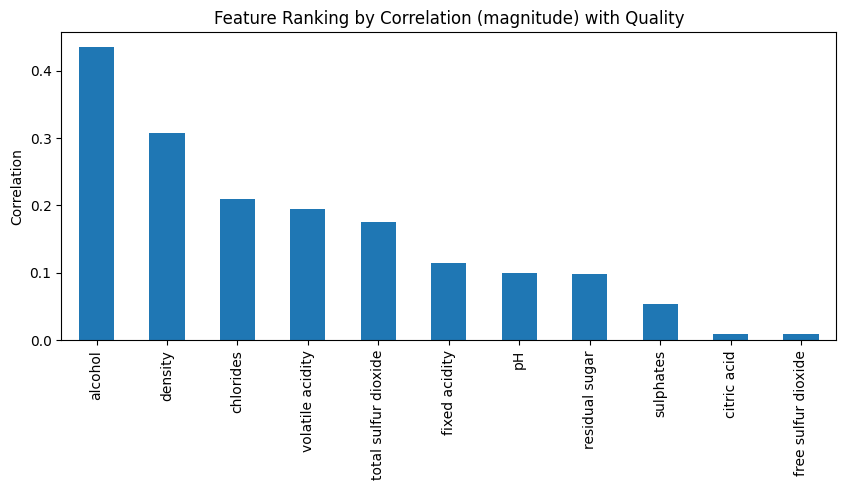

In [14]:
plt.figure(figsize=(10,4))
corr_scores.plot(kind="bar")
plt.title("Feature Ranking by Correlation (magnitude) with Quality")
plt.ylabel("Correlation")
plt.show()

Correlation ranks features based only on linear association with the target. However, real data patterns are rarely linear. A variable might carry important information even if its influence on the target is non-linear.

Since our predictive model is a random forest, which forms decision boundaries using hierarchical splits, it does not assume linear behaviour. It can leverage more complex relationships if the features contain such patterns.

#### Mutual Information

To account for this, we complement correlation scores with mutual information. MI quantifies how much information a feature contributes to the target, regardless of the form of the relationship. Features with low correlation but high MI may still be valuable to a non-linear model such as random forest.


We can utilise `mutual_info_regression` from scikit-learn to estimate this score for each feature and rank them accordingly. Together, correlation and MI provide a more complete basis for selecting useful predictors before modelling. It takes the predictors and target feature to calculate each predictor's mutual information with the target.

In [ ]:
# Mutual information
mi_scores = mutual_info_regression(X_train, y_train)    # returns an array of estimated MI values for each predictor
mi_scores = pd.Series(mi_scores, index=X_train.columns).sort_values(ascending=False)

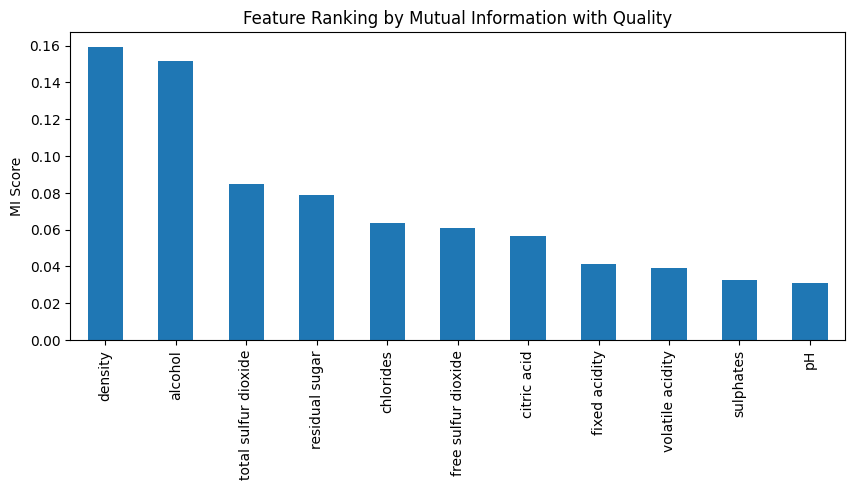

In [18]:
plt.figure(figsize=(10,4))
mi_scores.plot(kind="bar")
plt.title("Feature Ranking by Mutual Information with Quality")
plt.ylabel("MI Score")
plt.show()

The plots show that some features, such as `alcohol`, appear at the top under both metrics. These are strong candidates for feature selection.

Other features differ notably between the two rankings. Their effect on wine quality may not be captured fully by a linear measure alone. This is why combining correlation with MI leads to a more informed selection process.

### Feature Selection

First, let's train a model with all features to take as a baseline

In [26]:
base = RandomForestRegressor(random_state=1)

base.fit(X_train, y_train)
preds_base = base.predict(X_test)

rmse = math.sqrt(mean_squared_error(y_test, preds_base))
r2 = r2_score(y_test, preds_base)
mape = mean_absolute_percentage_error(y_test, preds_base)

rmse, r2, mape

(0.6031968406510668, 0.5239386037691124, 0.07735479834791059)

We can now select the top-k features and evaluate performance. An optimal point will give a good reduction in the number of features without affecting the performance too much. We will be using random forest regressor as the choice of model.

Let's take a set of k values, say `[5, 6, 7, 8, 9]`, and train the model on each value of k to compare.

In [46]:
k_values = [5, 6, 7, 8, 9]

results = {}    # this dict is for displaying the overall results
score = {}      # additional dict, for easier visualisation of scores (MAPE)

for k in k_values:
    
    top_k = mi_scores.head(k).index     # taking the top k features based on MI

    model = RandomForestRegressor(random_state=1)
    model.fit(X_train[top_k], y_train)
    
    preds = model.predict(X_test[top_k])
    rmse = math.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    mape = mean_absolute_percentage_error(y_test, preds)
    
    results[k] = (rmse, r2, mape)
    score[k] = mape 

print("Results: {'k': (rmse, r2, mape)}")
results

Results: {'k': (rmse, r2, mape)}


{5: (0.6718125042125418, 0.40947129161506723, 0.08487742954324587),
 6: (0.6374376320032239, 0.468356819101413, 0.08161303449951408),
 7: (0.6265281725672104, 0.48639876624447065, 0.07956362973760932),
 8: (0.6256236888098148, 0.487880610719886, 0.07927766034985423),
 9: (0.6163209639564802, 0.502997320232855, 0.07897033527696792)}

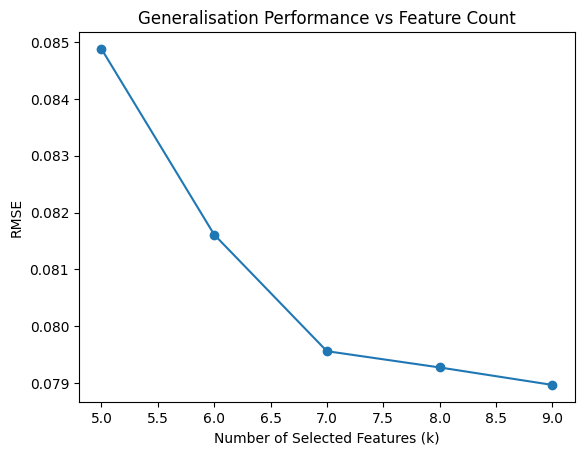

In [44]:
plt.plot(score.keys(), score.values(), marker="o")
plt.xlabel("Number of Selected Features (k)")
plt.ylabel("RMSE")
plt.title("Generalisation Performance vs Feature Count")
plt.show()

At 7 features, we see a minor elbow. There is a minor bump in the error value as we go from 7 to 6 or 5 features (7.9% to 8.1% to 8.5%). So, we can take the top 7 predictors from the feature set, which are: 

In [45]:
mi_scores.head(7)

density                 0.159430
alcohol                 0.151485
total sulfur dioxide    0.084756
residual sugar          0.078637
chlorides               0.063796
free sulfur dioxide     0.061086
citric acid             0.056486
dtype: float64

#### Feature Stability across Folds

A feature ranked highly once may simply be the result of sampling variability. To ensure reliability, we examine whether the same features consistently appear important across different folds of the data.

To check whether feature importance remains consistent across different samples of the data, we repeat the MI ranking under cross-validation. If a feature is truly useful, it should appear frequently among the top features, no matter which fold is used for training.

`KFold.split()` returns indices of training and validation rows `(train_idx, test_idx)` for samples of each fold. We only need the training indices here, because feature selection must always be based on training data to avoid information leakage.

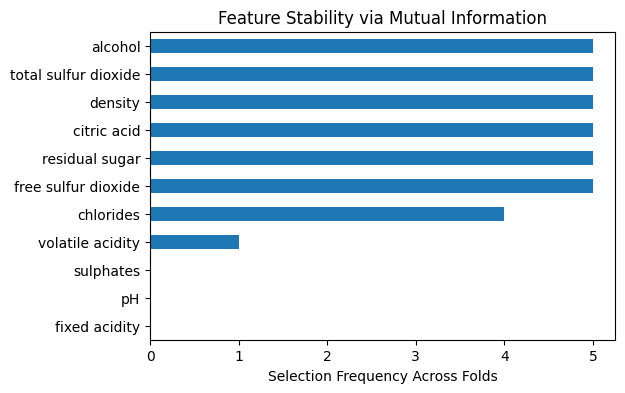

In [59]:
kf = KFold(n_splits=5, shuffle=True, random_state=1)

feature_counts = pd.Series(0, index=X.columns)      # this series will contain the number of times each feature appears in the top 7

for train_idx, _ in kf.split(X):        # taking only the training part, ignoring the validation rows

    mi_fold = mutual_info_regression(X.iloc[train_idx], y.iloc[train_idx])  # mutual info for rows used for training
    
    top7 = pd.Series(mi_fold, index=X.columns).sort_values(ascending=False).head(7).index      # we will take the top 7 features for each fold
    
    feature_counts[top7] += 1      # how often each feature appears in top 7

feature_counts.sort_values().plot(kind="barh", figsize=(6,4))
plt.xlabel("Selection Frequency Across Folds")
plt.title("Feature Stability via Mutual Information")
plt.show()

We can see that the 6 features `alcohol`, `total sulfur dioxide`, `density`, `residual sugar`, `free sulfur dioxide`, `citric acid` are in the top 7 features in each fold while `chlorides` appears in only 4 folds, whereas `volatile acidity` appears in 1 remaining fold. So we can safely take `chlorides` as the seventh feature.

Features selected frequently are stable contributors to performance. Inconsistently chosen features are more likely to be affected by fold-specific sampling patterns.

Feature selection should prioritise both relevance and stability when guiding model design.